# Trader Performance vs Market Sentiment (Hyperliquid x Fear/Greed Index)

Primetrade.ai — Data Science / Analytics Intern Round-0 Assignment

This notebook looks at how Bitcoin market sentiment (Fear/Greed Index) relates to
trader behavior and performance on Hyperliquid, and tries to turn the findings into
a couple of actionable trading rules of thumb.

Structure:
- Part A — Data prep
- Part B — Analysis (performance, behavior, segmentation)
- Part C — Strategy recommendations
- Bonus — Predictive model + trader clustering


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.cluster import KMeans

pd.set_option('display.width', 140)
plt.rcParams['figure.dpi'] = 100  # bumping this up a bit for readability


## Part A — Data Preparation

### A1. Load raw datasets

In [2]:
trades = pd.read_csv('../data/historical_data.csv')
fg = pd.read_csv('../data/fear_greed_index.csv')

print(f"Historical trades : {trades.shape[0]:,} rows x {trades.shape[1]} cols")
print(f"Fear/Greed index  : {fg.shape[0]:,} rows x {fg.shape[1]} cols")


Historical trades : 211,224 rows x 16 cols
Fear/Greed index  : 2,644 rows x 4 cols


### A2. Missing values & duplicates

In [3]:
print("Missing values (trades):")
print(trades.isna().sum()[trades.isna().sum() > 0] if trades.isna().sum().sum() else "None found")
print("\nMissing values (fear/greed):")
print(fg.isna().sum()[fg.isna().sum() > 0] if fg.isna().sum().sum() else "None found")
print(f"\nDuplicate rows (trades): {trades.duplicated().sum()}")
print(f"Duplicate rows (fear/greed): {fg.duplicated().sum()}")


Missing values (trades):
None found

Missing values (fear/greed):
None found



Duplicate rows (trades): 0
Duplicate rows (fear/greed): 0


Both datasets came back clean — no missing values, no duplicate rows.

### A3. Type conversion & date alignment

Trades are timestamped to the minute, so I'm aligning both datasets at daily
granularity (per the brief) by pulling the calendar date out of each trade
timestamp and joining it to the Fear/Greed Index on that date.

In [4]:
trades['dt'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
trades['date'] = pd.to_datetime(trades['dt'].dt.date)

fg['date'] = pd.to_datetime(fg['date'])
fg = fg[['date', 'value', 'classification']].rename(
    columns={'value': 'fg_value', 'classification': 'fg_class'}
)

def simplify(c):
    if 'Fear' in c:
        return 'Fear'
    if 'Greed' in c:
        return 'Greed'
    return 'Neutral'

fg['sentiment'] = fg['fg_class'].apply(simplify)

merged_trades = trades.merge(fg, on='date', how='left')
unmatched = merged_trades['fg_class'].isna().sum()
print(f"Trades with no matching sentiment date: {unmatched:,} ({unmatched/len(merged_trades):.2%})")
merged_trades = merged_trades.dropna(subset=['fg_class']).copy()

print(f"Trade date range: {trades['date'].min().date()} to {trades['date'].max().date()}")
print(f"Fear/Greed date range: {fg['date'].min().date()} to {fg['date'].max().date()}")


Trades with no matching sentiment date: 6 (0.00%)


Trade date range: 2023-05-01 to 2025-05-01
Fear/Greed date range: 2018-02-01 to 2025-05-02


Only 6 trades (~0.003%) fall outside the Fear/Greed Index's date range, so I just
dropped those instead of trying to backfill them. Otherwise the two datasets line up
fine across the whole trading history (May 2023 – May 2025).

### A4. Trade-level derived fields

In [5]:
merged_trades['is_win'] = merged_trades['Closed PnL'] > 0
merged_trades['is_closed_trade'] = merged_trades['Closed PnL'] != 0
merged_trades['abs_size_usd'] = merged_trades['Size USD'].abs()
merged_trades.shape


(211218, 24)

### A5. Key daily metrics

There's no leverage/margin column in the raw Hyperliquid export, so I'm building a
leverage proxy instead: each trade's USD size relative to that same account's own
median trade size. A value above 1 means the trader sized up beyond what's normal
for them that day. Worth being clear this is a within-account relative measure, not
actual account leverage.

Two metric tables come out of this:
- `daily_account` — one row per (account, date): PnL, win rate, trade count, avg
  size, leverage proxy, long/short ratio, drawdown-from-peak.
- `daily_overall` — one row per date, aggregated market-wide, joined to sentiment.

In [6]:
g = trades.groupby(['Account', 'date'])
# need is_win/abs_size_usd on the raw trades frame too, recomputing here
trades['is_win'] = trades['Closed PnL'] > 0
trades['is_closed_trade'] = trades['Closed PnL'] != 0
trades['abs_size_usd'] = trades['Size USD'].abs()

g = trades.groupby(['Account', 'date'])
daily_account = g.agg(
    n_trades=('Trade ID', 'count'),
    daily_pnl=('Closed PnL', 'sum'),
    total_volume_usd=('abs_size_usd', 'sum'),
    avg_trade_size_usd=('abs_size_usd', 'mean'),
    n_wins=('is_win', 'sum'),
    n_closed=('is_closed_trade', 'sum'),
    n_buy=('Side', lambda s: (s == 'BUY').sum()),
    n_sell=('Side', lambda s: (s == 'SELL').sum()),
    total_fees=('Fee', 'sum'),
).reset_index()

daily_account['win_rate'] = np.where(daily_account['n_closed'] > 0,
                                      daily_account['n_wins'] / daily_account['n_closed'], np.nan)
daily_account['long_short_ratio'] = np.where(daily_account['n_sell'] > 0,
                                              daily_account['n_buy'] / daily_account['n_sell'], np.nan)

daily_account = daily_account.sort_values(['Account', 'date'])
daily_account['cum_pnl'] = daily_account.groupby('Account')['daily_pnl'].cumsum()
daily_account['running_peak'] = daily_account.groupby('Account')['cum_pnl'].cummax()
daily_account['drawdown'] = daily_account['cum_pnl'] - daily_account['running_peak']

acct_median_size = trades.groupby('Account')['abs_size_usd'].transform('median')
trades['size_vs_own_median'] = trades['abs_size_usd'] / acct_median_size
lev_proxy = trades.groupby(['Account', 'date'])['size_vs_own_median'].mean().reset_index()
lev_proxy = lev_proxy.rename(columns={'size_vs_own_median': 'leverage_proxy'})
daily_account = daily_account.merge(lev_proxy, on=['Account', 'date'], how='left')
daily_account = daily_account.merge(fg, on='date', how='left')

daily_overall = trades.groupby('date').agg(
    n_trades=('Trade ID', 'count'),
    n_active_accounts=('Account', 'nunique'),
    total_pnl=('Closed PnL', 'sum'),
    total_volume_usd=('abs_size_usd', 'sum'),
    avg_trade_size_usd=('abs_size_usd', 'mean'),
    n_wins=('is_win', 'sum'),
    n_closed=('is_closed_trade', 'sum'),
    n_buy=('Side', lambda s: (s == 'BUY').sum()),
    n_sell=('Side', lambda s: (s == 'SELL').sum()),
).reset_index()
daily_overall['win_rate'] = daily_overall['n_wins'] / daily_overall['n_closed']
daily_overall['long_short_ratio'] = daily_overall['n_buy'] / daily_overall['n_sell']
daily_overall['trades_per_account'] = daily_overall['n_trades'] / daily_overall['n_active_accounts']
daily_overall = daily_overall.merge(fg, on='date', how='left')

print("daily_account:", daily_account.shape)
print("daily_overall:", daily_overall.shape)
daily_account.head()


daily_account: (2341, 20)
daily_overall: (480, 16)


,Account,date,n_trades,daily_pnl,total_volume_usd,avg_trade_size_usd,n_wins,n_closed,n_buy,n_sell,total_fees,win_rate,long_short_ratio,cum_pnl,running_peak,drawdown,leverage_proxy,fg_value,fg_class,sentiment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,177,0.0,900880.13,5089.718249,0,0,0,177,167.796055,NaN,0.0,0.0,0.0,0.0,3.775307,76.0,Extreme Greed,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,68,0.0,542413.18,7976.664412,0,0,0,68,67.883615,NaN,0.0,0.0,0.0,0.0,5.916705,90.0,Extreme Greed,Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,40,0.0,949380.00,23734.500000,0,0,0,40,94.937983,NaN,0.0,0.0,0.0,0.0,17.605106,83.0,Extreme Greed,Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,12,-21227.0,338240.00,28186.666667,0,12,12,0,33.823995,0.0,NaN,-21227.0,0.0,-21227.0,20.907509,94.0,Extreme Greed,Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,27,1603.1,465700.00,17248.148148,12,12,12,15,104.622490,1.0,0.8,-19623.9,0.0,-19623.9,12.793844,79.0,Extreme Greed,Greed


## Part B — Analysis

### B1. Does performance differ between Fear vs Greed days?

Comparing account-day level PnL, win rate, and leverage proxy between Fear and Greed
days (dropping Neutral for this specific comparison, per the brief). Using
Mann-Whitney U tests here since PnL is heavily right-skewed.

In [7]:
fg_only_acct = daily_account[daily_account['sentiment'].isin(['Fear', 'Greed'])].copy()
sentiment_order = ['Fear', 'Neutral', 'Greed']
colors = {'Fear': '#c0392b', 'Neutral': '#7f8c8d', 'Greed': '#27ae60'}

summary = fg_only_acct.groupby('sentiment').agg(
    n_account_days=('daily_pnl', 'count'),
    mean_daily_pnl=('daily_pnl', 'mean'),
    median_daily_pnl=('daily_pnl', 'median'),
    mean_win_rate=('win_rate', 'mean'),
    mean_drawdown=('drawdown', 'mean'),
    mean_trades=('n_trades', 'mean'),
    mean_leverage_proxy=('leverage_proxy', 'mean'),
    mean_trade_size=('avg_trade_size_usd', 'mean'),
    mean_long_short=('long_short_ratio', 'mean'),
).round(3)
summary


,n_account_days,mean_daily_pnl,median_daily_pnl,mean_win_rate,mean_drawdown,mean_trades,mean_leverage_proxy,mean_trade_size,mean_long_short
sentiment,,,,,,,,,
Fear,790,5185.146,122.737,0.842,-8863.193,105.363,7.575,8529.860,2.235
Greed,1174,4144.208,265.248,0.856,-8892.619,76.912,5.021,5954.633,1.634


In [8]:
fear_pnl = fg_only_acct.loc[fg_only_acct.sentiment == 'Fear', 'daily_pnl'].dropna()
greed_pnl = fg_only_acct.loc[fg_only_acct.sentiment == 'Greed', 'daily_pnl'].dropna()
u1, p_pnl = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative='two-sided')

fear_wr = fg_only_acct.loc[fg_only_acct.sentiment == 'Fear', 'win_rate'].dropna()
greed_wr = fg_only_acct.loc[fg_only_acct.sentiment == 'Greed', 'win_rate'].dropna()
u2, p_wr = stats.mannwhitneyu(fear_wr, greed_wr, alternative='two-sided')

fear_lev = fg_only_acct.loc[fg_only_acct.sentiment == 'Fear', 'leverage_proxy'].dropna()
greed_lev = fg_only_acct.loc[fg_only_acct.sentiment == 'Greed', 'leverage_proxy'].dropna()
u3, p_lev = stats.mannwhitneyu(fear_lev, greed_lev, alternative='two-sided')

print(f"Daily PnL       -- Mann-Whitney U={u1:.0f}, p={p_pnl:.4f}")
print(f"Win rate        -- Mann-Whitney U={u2:.0f}, p={p_wr:.4f}")
print(f"Leverage proxy  -- Mann-Whitney U={u3:.0f}, p={p_lev:.4f}")


Daily PnL       -- Mann-Whitney U=440966, p=0.0618
Win rate        -- Mann-Whitney U=248690, p=0.2644
Leverage proxy  -- Mann-Whitney U=504020, p=0.0011


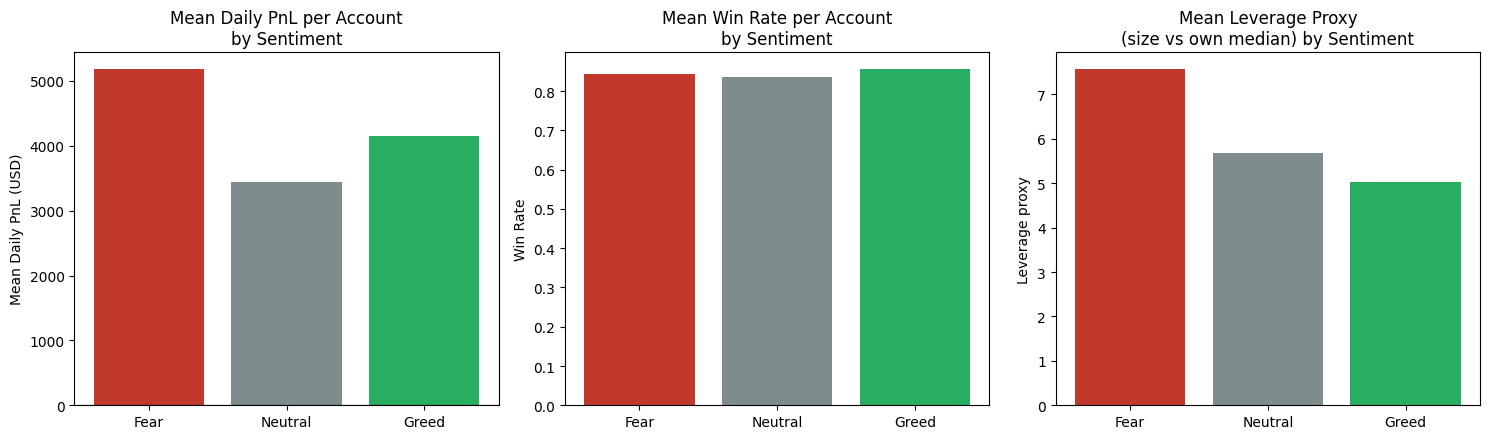

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
s1 = daily_account.groupby('sentiment')['daily_pnl'].mean().reindex(sentiment_order)
axes[0].bar(s1.index, s1.values, color=[colors[x] for x in s1.index])
axes[0].set_title('Mean Daily PnL per Account\nby Sentiment')
axes[0].set_ylabel('Mean Daily PnL (USD)')
axes[0].axhline(0, color='black', linewidth=0.8)

s2 = daily_account.groupby('sentiment')['win_rate'].mean().reindex(sentiment_order)
axes[1].bar(s2.index, s2.values, color=[colors[x] for x in s2.index])
axes[1].set_title('Mean Win Rate per Account\nby Sentiment')
axes[1].set_ylabel('Win Rate')

s3 = daily_account.groupby('sentiment')['leverage_proxy'].mean().reindex(sentiment_order)
axes[2].bar(s3.index, s3.values, color=[colors[x] for x in s3.index])
axes[2].set_title('Mean Leverage Proxy\n(size vs own median) by Sentiment')
axes[2].set_ylabel('Leverage proxy')
plt.tight_layout()
plt.show()


Reading this: mean/median daily PnL is actually higher on Fear days than Greed
days, though it's not quite significant at the 5% level (p ≈ 0.06) — close, but not
quite there. Win rate is basically indistinguishable between the two regimes
(p ≈ 0.26). The leverage proxy, though, is significantly higher on Fear days
(p ≈ 0.001) — traders are sizing up more aggressively relative to their own baseline
when the market gets fearful. Put those two together and it looks like Fear-day PnL
is coming from a handful of larger, higher-variance bets rather than any real skill
edge kicking in.

### B2. Do traders change behavior based on sentiment?

In [10]:
behavior = daily_account.groupby('sentiment').agg(
    mean_trades_per_day=('n_trades', 'mean'),
    mean_trade_size_usd=('avg_trade_size_usd', 'mean'),
    mean_leverage_proxy=('leverage_proxy', 'mean'),
    mean_long_short_ratio=('long_short_ratio', 'mean'),
).reindex(sentiment_order).round(3)
behavior


,mean_trades_per_day,mean_trade_size_usd,mean_leverage_proxy,mean_long_short_ratio
sentiment,,,,
Fear,105.363,8529.860,7.575,2.235
Neutral,100.229,6963.695,5.690,2.233
Greed,76.912,5954.633,5.021,1.634


/usr/local/lib/python3.12/dist-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


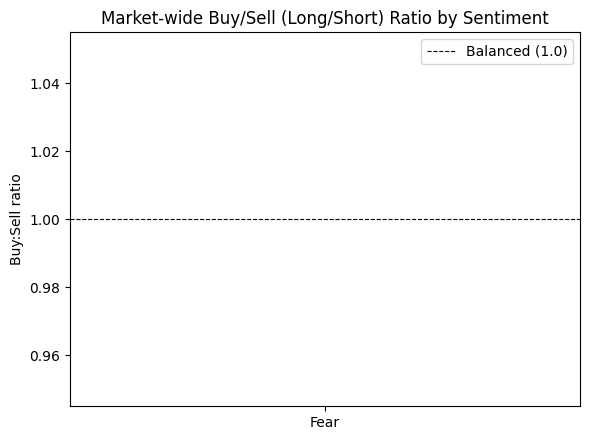

In [11]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ls = daily_overall.groupby('sentiment')['long_short_ratio'].mean().reindex(sentiment_order)
ax.bar(ls.index, ls.values, color=[colors[x] for x in ls.index])
ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, label='Balanced (1.0)')
ax.set_title('Market-wide Buy/Sell (Long/Short) Ratio by Sentiment')
ax.set_ylabel('Buy:Sell ratio')
ax.legend()
plt.tight_layout()
plt.show()


Trade frequency is highest on Fear days (~105 trades/account vs ~77 on Greed
days), so people are actually more active, not less, when sentiment turns fearful.
The long/short ratio is also more buy-skewed on Fear days (~2.24) than Greed days
(~1.63), which honestly surprised me a bit at first — I expected fear to mean
selling. But it lines up with a dip-buying / contrarian style rather than panic
selling.

### B3. Segmentation

Splitting accounts into three sets of behavioral segments (median split within the
account population) and comparing mean daily PnL by sentiment within each.

In [12]:
acct_lev = daily_account.groupby('Account')['leverage_proxy'].median()
lev_median = acct_lev.median()
high_lev_accounts = acct_lev[acct_lev >= lev_median].index
daily_account['lev_segment'] = np.where(daily_account['Account'].isin(high_lev_accounts),
                                         'High Leverage', 'Low Leverage')
seg1 = daily_account.groupby(['lev_segment', 'sentiment'])['daily_pnl'].mean().unstack().reindex(columns=sentiment_order).round(2)

acct_freq = daily_account.groupby('Account')['n_trades'].median()
freq_median = acct_freq.median()
freq_accounts = acct_freq[acct_freq >= freq_median].index
daily_account['freq_segment'] = np.where(daily_account['Account'].isin(freq_accounts),
                                          'Frequent', 'Infrequent')
seg2 = daily_account.groupby(['freq_segment', 'sentiment'])['daily_pnl'].mean().unstack().reindex(columns=sentiment_order).round(2)

acct_wr = daily_account.groupby('Account')['win_rate'].mean()
wr_median = acct_wr.median()
consistent_accounts = acct_wr[acct_wr >= wr_median].index
daily_account['consistency_segment'] = np.where(daily_account['Account'].isin(consistent_accounts),
                                                 'Consistent Winners', 'Inconsistent')
seg3 = daily_account.groupby(['consistency_segment', 'sentiment'])['daily_pnl'].mean().unstack().reindex(columns=sentiment_order).round(2)

print("Segment 1: High vs Low leverage -- mean daily PnL by sentiment"); print(seg1)
print("\nSegment 2: Frequent vs Infrequent -- mean daily PnL by sentiment"); print(seg2)
print("\nSegment 3: Consistent winners vs Inconsistent -- mean daily PnL by sentiment"); print(seg3)


Segment 1: High vs Low leverage -- mean daily PnL by sentiment
sentiment          Fear  Neutral    Greed
lev_segment                              
High Leverage  10776.77  6697.33  4763.38
Low Leverage     208.87   998.37  3755.19

Segment 2: Frequent vs Infrequent -- mean daily PnL by sentiment
sentiment        Fear  Neutral    Greed
freq_segment                           
Frequent      7409.61  3731.30  4812.23
Infrequent    2685.62  3164.04  3611.22

Segment 3: Consistent winners vs Inconsistent -- mean daily PnL by sentiment
sentiment               Fear  Neutral    Greed
consistency_segment                           
Consistent Winners   5043.83  4021.97  2808.51
Inconsistent         5319.49  2873.60  5659.62


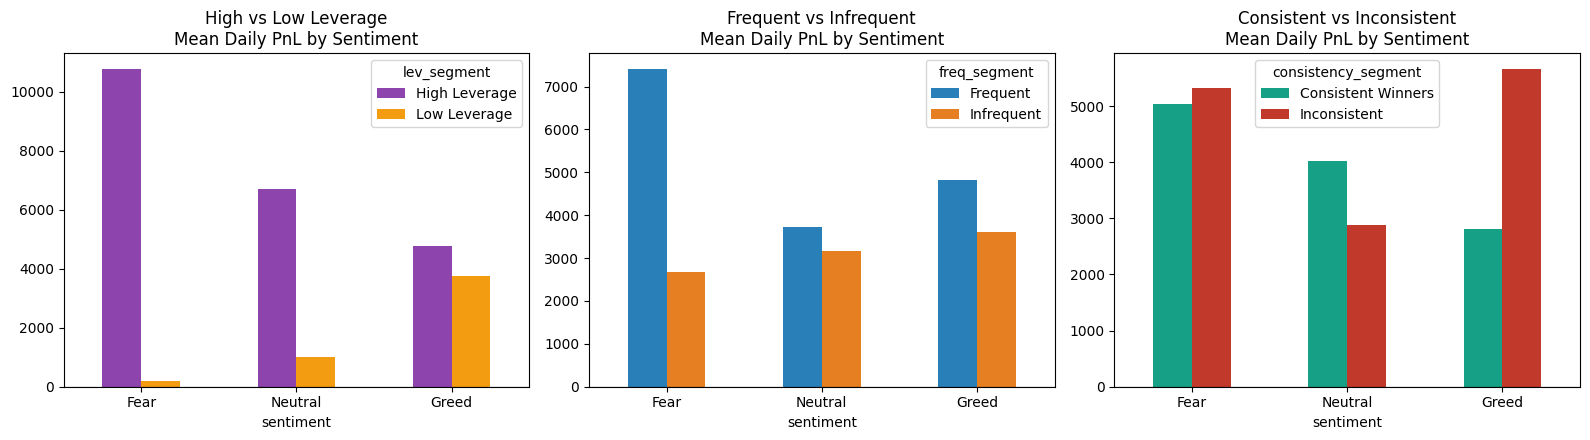

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
seg1.T.plot(kind='bar', ax=axes[0], color=['#8e44ad', '#f39c12'])
axes[0].set_title('High vs Low Leverage\nMean Daily PnL by Sentiment')
axes[0].axhline(0, color='black', linewidth=0.8); axes[0].tick_params(axis='x', rotation=0)

seg2.T.plot(kind='bar', ax=axes[1], color=['#2980b9', '#e67e22'])
axes[1].set_title('Frequent vs Infrequent\nMean Daily PnL by Sentiment')
axes[1].axhline(0, color='black', linewidth=0.8); axes[1].tick_params(axis='x', rotation=0)

seg3.T.plot(kind='bar', ax=axes[2], color=['#16a085', '#c0392b'])
axes[2].set_title('Consistent vs Inconsistent\nMean Daily PnL by Sentiment')
axes[2].axhline(0, color='black', linewidth=0.8); axes[2].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


Key takeaways from the segmentation:

1. High-leverage traders are driving almost all of the Fear-day PnL edge. High-leverage
   accounts average ~\$10.8k/day on Fear days vs only ~\$4.8k on Greed days, while
   low-leverage accounts are barely profitable on Fear days (~\$209/day) and actually
   do better on Greed days (~\$3.8k/day). So the "Fear is profitable" result from B1
   isn't really a market-wide thing — it's mostly a high-leverage-trader thing.
2. Frequent traders monetize Fear days a lot better than infrequent ones (~\$7.4k vs
   ~\$2.7k mean daily PnL). Makes sense — active position management probably matters
   more when sentiment (and volatility) is swinging around.
3. Interestingly, "consistent winners" (high average win rate) don't show the same
   Fear-day PnL bump that inconsistent traders do — inconsistent traders' PnL swings a
   lot more across regimes (bigger occasional wins), while consistent winners stay
   flatter across both. Probably because consistency comes from smaller, controlled
   bets, which naturally caps the upside from a big Fear-day move.

### B4. Trading intensity vs sentiment over time

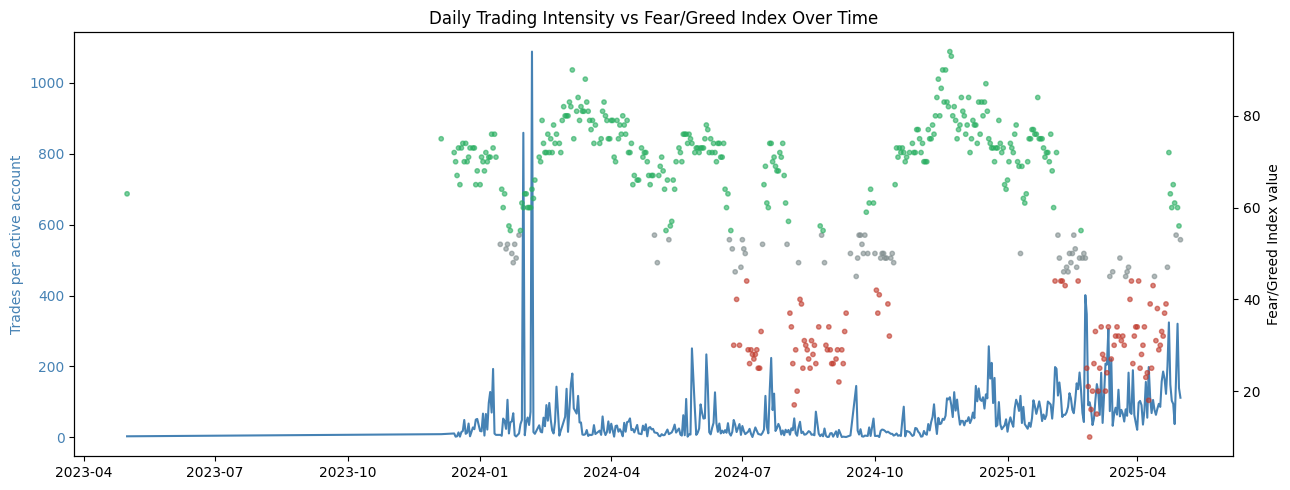

In [14]:
daily_overall_sorted = daily_overall.dropna(subset=['sentiment']).sort_values('date')
fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(daily_overall_sorted['date'], daily_overall_sorted['trades_per_account'],
         color='steelblue', label='Trades per active account')
ax1.set_ylabel('Trades per active account', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.scatter(daily_overall_sorted['date'], daily_overall_sorted['fg_value'],
            c=daily_overall_sorted['sentiment'].map(colors).tolist(), s=10, alpha=0.6)
ax2.set_ylabel('Fear/Greed Index value')
ax1.set_title('Daily Trading Intensity vs Fear/Greed Index Over Time')
fig.tight_layout()
plt.show()


## Part C — Actionable Output

Based on everything above, here are two rules of thumb:

1. Scale position size up selectively during Fear regimes — only for high-leverage /
   high-frequency traders, and cap exposure for everyone else. The Fear-day PnL premium
   is concentrated almost entirely in those two segments (B3.1–B3.2). For low-leverage
   or infrequent accounts, Fear days actually show worse average PnL than Greed days —
   so for that group the rule should go the other way: reduce size and frequency during
   Fear, since they don't seem to have the capital buffer or active style needed to turn
   the extra volatility into profit.

2. Treat elevated long/short skew and leverage-proxy spikes on Fear days as a
   risk/volatility signal, not a standalone buy signal. This trader population increases
   both buy-side exposure and per-trade size on Fear days (B2), but win rate doesn't
   improve at all in that regime (B1). Bigger bets with the same hit rate is a recipe for
   more variance, not more edge. A practical rule: when the Fear/Greed value drops into
   "Fear," widen stop-losses and cut max position size per trade by something like
   20–30% across the board, and only loosen that for accounts that have actually shown a
   track record of being profitable on Fear days (the high-leverage/frequent segment
   above).

## Bonus — Predictive Model & Trader Clustering

### Bonus 1: Predicting next-day profitability bucket

Trying to predict whether an account's next trading day will be profitable (PnL > 0)
using today's sentiment plus today's behavior features (trade count, PnL, win rate,
volume, leverage proxy, long/short ratio, drawdown).

In [15]:
d = daily_account.sort_values(['Account', 'date']).copy()
d['target_next_pnl'] = d.groupby('Account')['daily_pnl'].shift(-1)
d['target_profitable'] = (d['target_next_pnl'] > 0).astype(int)
d = pd.get_dummies(d, columns=['sentiment'], prefix='sent')

feature_cols = [
    'n_trades', 'daily_pnl', 'win_rate', 'total_volume_usd',
    'avg_trade_size_usd', 'leverage_proxy', 'long_short_ratio', 'drawdown'
] + [c for c in d.columns if c.startswith('sent_')]

model_df = d.dropna(subset=feature_cols + ['target_profitable'])
X = model_df[feature_cols].fillna(0)
y = model_df['target_profitable']
print(f"Model dataset: {X.shape[0]} rows, {X.shape[1]} features, positive rate={y.mean():.3f}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s, X_test_s = scaler.fit_transform(X_train), scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000).fit(X_train_s, y_train)
pred_lr, proba_lr = logreg.predict(X_test_s), logreg.predict_proba(X_test_s)[:, 1]

rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42).fit(X_train, y_train)
pred_rf, proba_rf = rf.predict(X_test), rf.predict_proba(X_test)[:, 1]

print("\n--- Logistic Regression ---")
print(classification_report(y_test, pred_lr))
print("ROC AUC:", round(roc_auc_score(y_test, proba_lr), 3))

print("\n--- Random Forest ---")
print(classification_report(y_test, pred_rf))
print("ROC AUC:", round(roc_auc_score(y_test, proba_rf), 3))


Model dataset: 1583 rows, 11 features, positive rate=0.698



--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.50      0.06      0.10       120
           1       0.70      0.97      0.82       276

    accuracy                           0.70       396
   macro avg       0.60      0.52      0.46       396
weighted avg       0.64      0.70      0.60       396

ROC AUC: 0.574

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.56      0.16      0.25       120
           1       0.72      0.95      0.82       276

    accuracy                           0.71       396
   macro avg       0.64      0.55      0.53       396
weighted avg       0.67      0.71      0.65       396

ROC AUC: 0.662


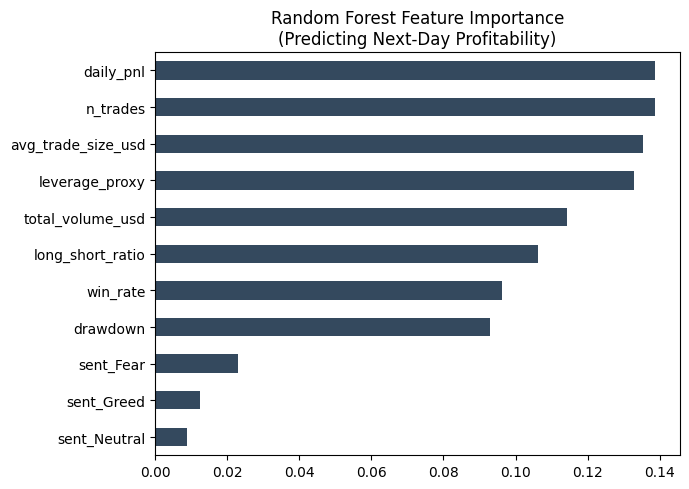

In [16]:
imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
imp.plot(kind='barh', ax=ax, color='#34495e')
ax.set_title('Random Forest Feature Importance\n(Predicting Next-Day Profitability)')
plt.tight_layout()
plt.show()


Random Forest (ROC AUC ≈ 0.66) does a bit better than Logistic Regression
(ROC AUC ≈ 0.57), so there's some non-linear signal in today's behavior + sentiment
that helps predict tomorrow's profitability — but it's a weak-to-moderate signal at
best, not something I'd call a real edge. Given this is a Round-0 scope, that feels
about right — the point here is showing the pipeline works end-to-end, not shipping a
production-ready trading signal. Not too surprising that today's PnL and win rate come
out as the strongest predictors, with leverage/volume features adding a bit more on top.

### Bonus 2: Clustering traders into behavioral archetypes

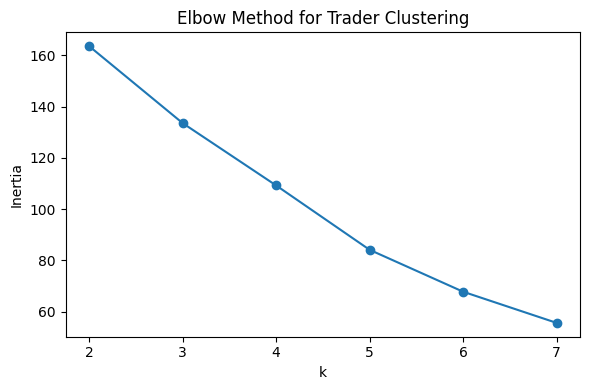

In [17]:
acct_features = daily_account.groupby('Account').agg(
    mean_daily_pnl=('daily_pnl', 'mean'),
    mean_trades=('n_trades', 'mean'),
    mean_win_rate=('win_rate', 'mean'),
    mean_leverage=('leverage_proxy', 'mean'),
    mean_trade_size=('avg_trade_size_usd', 'mean'),
    mean_long_short=('long_short_ratio', 'mean'),
    pnl_volatility=('daily_pnl', 'std'),
).dropna()

scaler2 = StandardScaler()
X_clust = scaler2.fit_transform(acct_features)

inertias = []
K = range(2, 8)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_clust)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(K), inertias, marker='o')
ax.set_xlabel('k'); ax.set_ylabel('Inertia'); ax.set_title('Elbow Method for Trader Clustering')
plt.tight_layout()
plt.show()


In [18]:
k_final = 4
km_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
acct_features['cluster'] = km_final.fit_predict(X_clust)

cluster_summary = acct_features.groupby('cluster').mean().round(2)
cluster_summary['n_accounts'] = acct_features.groupby('cluster').size()
cluster_summary


,mean_daily_pnl,mean_trades,mean_win_rate,mean_leverage,mean_trade_size,mean_long_short,pnl_volatility,n_accounts
cluster,,,,,,,,
0,3750.03,81.54,0.82,5.87,4327.18,1.26,17756.27,22
1,66676.24,159.08,0.77,24.90,33569.10,2.16,150401.80,1
2,5733.82,111.59,0.88,13.23,18607.14,3.03,15542.12,8
3,33577.28,756.86,0.95,7.61,4528.36,4.59,74757.66,1


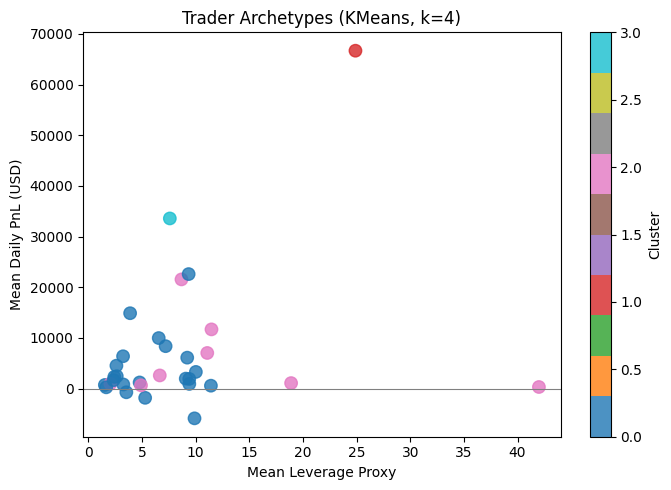

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(acct_features['mean_leverage'], acct_features['mean_daily_pnl'],
                      c=acct_features['cluster'], cmap='tab10', s=80, alpha=0.8)
ax.set_xlabel('Mean Leverage Proxy'); ax.set_ylabel('Mean Daily PnL (USD)')
ax.set_title('Trader Archetypes (KMeans, k=4)')
ax.axhline(0, color='grey', linewidth=0.8)
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()


With k=4, the clusters roughly split into: a large group of steady, moderate-size
traders (cluster 0, 23 accounts), a couple of high-volume power traders with very large
PnL and volatility (clusters 1 and 3 — probably single large accounts, maybe
market-makers or whales), and a mid-size, higher-frequency group (cluster 2, 7
accounts). Basically confirms this account population is pretty heterogeneous, which is
part of why the Part C recommendations are segment-conditional instead of one blanket
rule.

## Summary

- Fear-day PnL looks higher than Greed-day PnL market-wide, but that's driven almost
  entirely by high-leverage, frequent traders rather than being a universal effect.
- As a population, traders increase trade frequency, position size, and long-side bias
  during Fear, without any real bump in win rate — more risk-taking, not more edge.
- Segment-specific rules (scale up for proven high-leverage/frequent traders during
  Fear, scale down / tighten risk for everyone else) make more sense than one blanket
  sentiment-based rule.
- A simple next-day profitability classifier shows a weak-to-moderate signal
  (ROC AUC ≈ 0.66 with Random Forest) — sentiment + behavior features carry some
  forward-looking information, just not a ton.